In [1]:
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#Load validation data
data0 = np.loadtxt("./ercoftac_t3a_cf.dat",skiprows=0)

In [4]:
#Load openfoam data
data1 = np.loadtxt("../RANS-kklo/surfacesDict/15000/grad(U)_wall.raw",skiprows=2)
data2 = np.loadtxt("../RANS-kOmegaSSTLM/surfacesDict/15000/grad(U)_wall.raw",skiprows=2)
data3 = np.loadtxt("../RANS-koSSTv1/surfacesDict/15000/grad(U)_wall.raw",skiprows=2)
data4 = np.loadtxt("../RANS-launderSharmaKE/surfacesDict/15000/grad(U)_wall.raw",skiprows=2)
data5 = np.loadtxt("../RANS-liencubicKE/surfacesDict/15000/grad(U)_wall.raw",skiprows=2)
data6 = np.loadtxt("../RANS-realizableKE/surfacesDict/15000/grad(U)_wall.raw",skiprows=2)
data7 = np.loadtxt("../RANS-rngKE/surfacesDict/15000/grad(U)_wall.raw",skiprows=2)
data8 = np.loadtxt("../RANS-SA/surfacesDict/15000/grad(U)_wall.raw",skiprows=2)

In [5]:
#Define variables
#x=np.linspace(-1,3,1000)
x=data1[:,0]

U = 5.4
nu = 1.5e-05
rho = 1.186

In [6]:
#Compute Re_x
re_x=U*x/nu

In [7]:
#Compute tau laminar and cf from correlation
taulam = nu*U*np.sqrt(U/(nu*x))*0.332
cflam_x = 2*taulam/(U**2)

In [8]:
#Compute tau turbulent and cf from correlation - white
tauturb = 0.455/(np.log(0.06*re_x))**2
cfturb_x=2*tauturb/(U**2)

In [9]:
#Compute friction coefficient using grad(U) computed in openfoam
cf_x1=2*data1[:,6]*nu/(U**2)
cf_x2=2*data2[:,6]*nu/(U**2)
cf_x3=2*data3[:,6]*nu/(U**2)
cf_x4=2*data4[:,6]*nu/(U**2)
cf_x5=2*data5[:,6]*nu/(U**2)
cf_x6=2*data6[:,6]*nu/(U**2)
cf_x7=2*data7[:,6]*nu/(U**2)
cf_x8=2*data8[:,6]*nu/(U**2)

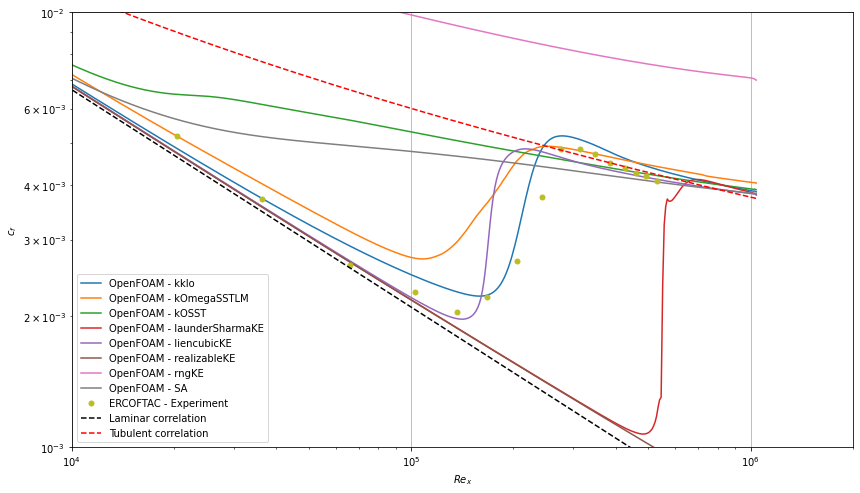

In [10]:
#Plot law of wall

#Plot profiles
plt.figure(figsize=(14, 8))


plt.plot(re_x,cf_x1,label='OpenFOAM - kklo')
plt.plot(re_x,cf_x2,label='OpenFOAM - kOmegaSSTLM')
plt.plot(re_x,cf_x3,label='OpenFOAM - kOSST')
plt.plot(re_x,cf_x4,label='OpenFOAM - launderSharmaKE')

plt.plot(re_x,cf_x5,label='OpenFOAM - liencubicKE')
plt.plot(re_x,cf_x6,label='OpenFOAM - realizableKE')
plt.plot(re_x,cf_x7,label='OpenFOAM - rngKE')
plt.plot(re_x,cf_x8,label='OpenFOAM - SA')


plt.plot(data0[:,0],data0[:,1],'o', ms=5,label='ERCOFTAC - Experiment')
plt.plot(re_x,cflam_x,'--', c='black',ms=5,label='Laminar correlation')
plt.plot(re_x,tauturb,'--', c='red',ms=5,label='Tubulent correlation')
#plt.plot(re_x,cfturb_x,'-', ms=5,label='Tubulent correlation')

#plt.plot(yp,up1,label='Log-law)

plt.xscale('log')
plt.yscale('log')

plt.xlim(10000,2000000)
plt.ylim(0.001,0.01)

plt.xlabel("$Re_x$")
plt.ylabel("$c_f$")

plt.grid()
plt.legend(loc=0)


#plt.savefig('cf5000.png')